In [1]:
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd

In [33]:
db_path = '../database/haslach.db'
conn = sqlite3.connect(db_path)
df = pd.read_sql_query("SELECT * FROM main ORDER BY timestamp", conn)
conn.close()
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True).dt.tz_convert('Europe/Berlin')
df['control_el'] = (df['controller_state'] =='EL')*1
df = df.set_index('timestamp', drop=True)

df = df[['fhs280_t1', 'fhs280_t2', 'fhs280_compressor', 'fhs280_elpatron', 'controller_state', 'power_bwwp','power_mains', 'fan_relay_state']]

In [53]:
start = '2026-07-20T06:00'
stop = '2026-07-20T20:00'

df_sub = df.loc[start:].loc[:stop]

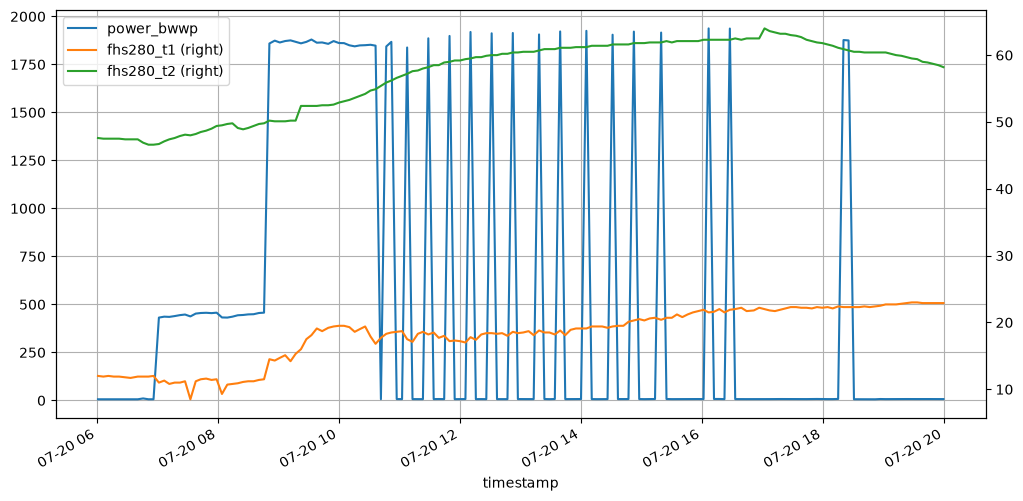

In [56]:
fig, ax = plt.subplots(figsize=(12, 6))

df_sub[['power_bwwp']].plot(ax=ax)
df_sub[['fhs280_t1', 'fhs280_t2']].plot(ax=ax, secondary_y=True)
secondary_y=True
ax.grid(True)

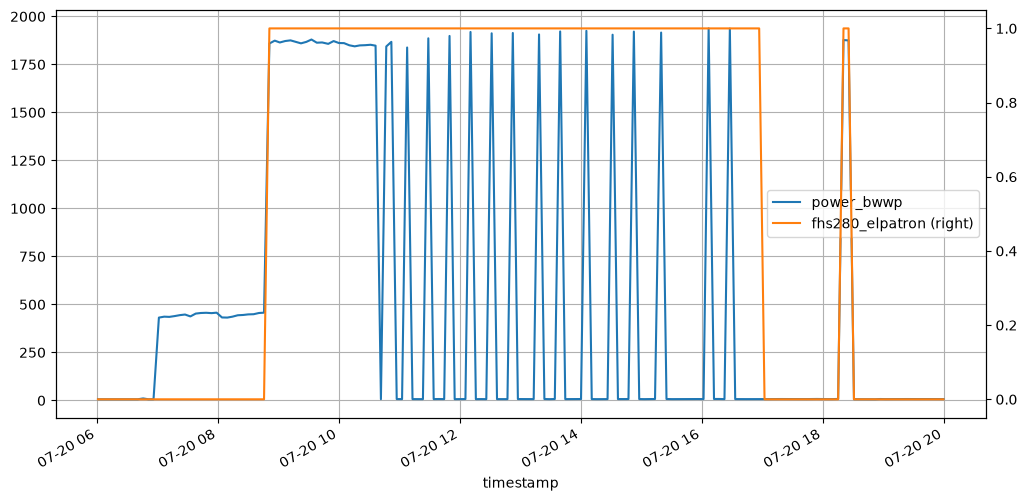

In [57]:
fig, ax = plt.subplots(figsize=(12, 6))

df_sub[['power_bwwp']].plot(ax=ax)
df_sub[['fhs280_elpatron']].plot(ax=ax, secondary_y=True)
ax.grid(True)

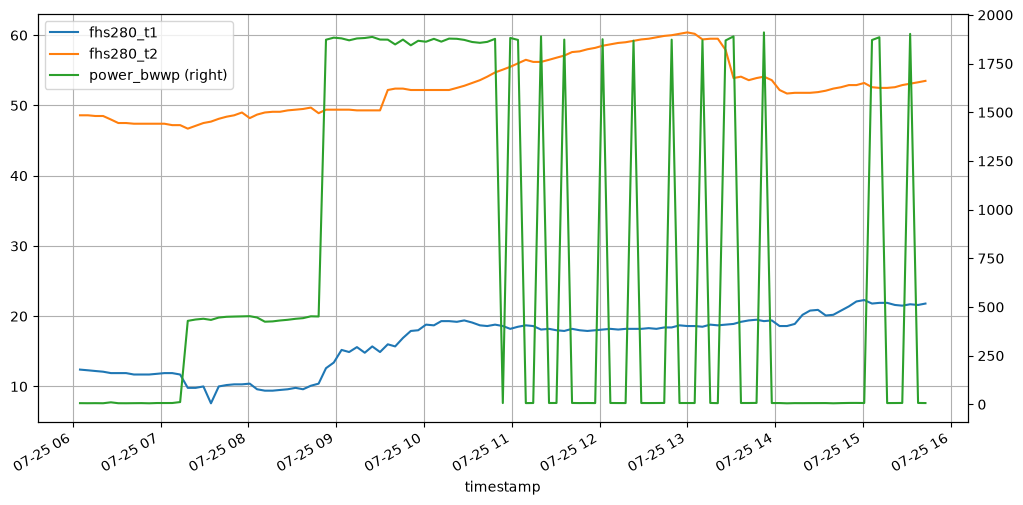

In [39]:
fig, ax = plt.subplots(figsize=(12, 6))

df_sub[['fhs280_t1', 'fhs280_t2']].plot(ax=ax)
df_sub[['power_bwwp']].plot(ax=ax, secondary_y=True)

ax.grid(True)

In [48]:
df['fhs280_t2'].idxmax()

Timestamp('2026-07-20 17:01:59.137674+0200', tz='Europe/Berlin')